In [79]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [80]:
df = pd.read_csv("../data/processed/cpi_oni.csv")
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

display(df.head())
display(df.tail())

,date,food_inflation,oni,month
0,2012-01-01,-0.21,-0.72,1
1,2012-02-01,4.45,-0.57,2
2,2012-03-01,7.09,-0.46,3
3,2012-04-01,9.32,-0.36,4
4,2012-05-01,9.70,-0.17,5


,date,food_inflation,oni,month
163,2025-08-01,-0.64,-0.28,8
164,2025-09-01,-2.33,-0.40,9
165,2025-10-01,-5.02,-0.51,10
166,2025-11-01,-3.91,-0.55,11
167,2025-12-01,-2.71,-0.54,12


In [81]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

Shape: (168, 4)

Missing values:
date              0
food_inflation    0
oni               0
month             0
dtype: int64

Date range:
2012-01-01 00:00:00 to 2025-12-01 00:00:00


In [82]:
TEST_SIZE = 24

train_df = df.iloc[:-TEST_SIZE].copy()
test_df = df.iloc[-TEST_SIZE:].copy()

print("Training:")
print(train_df["date"].min(), "→", train_df["date"].max())

print("\nTesting:")
print(test_df["date"].min(), "→", test_df["date"].max())

Training:
2012-01-01 00:00:00 → 2023-12-01 00:00:00

Testing:
2024-01-01 00:00:00 → 2025-12-01 00:00:00


In [83]:
features = ["food_inflation", "oni"]

feature_scaler = MinMaxScaler()

train_scaled = feature_scaler.fit_transform(
    train_df[features]
)

test_scaled = feature_scaler.transform(
    test_df[features]
)

In [84]:
target_scaler = MinMaxScaler()

target_scaler.fit(
    train_df[["food_inflation"]]
)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[17.89]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[-2.65]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[20.54]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['food_inflation']
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[0.13]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,144


In [85]:
def create_sequences(
    features,
    target,
    lookback
):
    X = []
    y = []

    for i in range(
        lookback,
        len(features)
    ):
        X.append(
            features[i - lookback:i]
        )

        y.append(
            target[i]
        )

    return (
        np.array(X),
        np.array(y)
    )

LOOKBACK = 12

In [86]:
train_target_scaled = target_scaler.transform(
    train_df[["food_inflation"]]
).flatten()

In [87]:
X_train_full, y_train_full = create_sequences(
    train_scaled,
    train_target_scaled,
    LOOKBACK
)

print("X shape:", X_train_full.shape)
print("y shape:", y_train_full.shape)

X shape: (132, 12, 2)
y shape: (132,)


In [88]:
VALIDATION_SIZE = 24

X_train = X_train_full[:-VALIDATION_SIZE]
y_train = y_train_full[:-VALIDATION_SIZE]

X_val = X_train_full[-VALIDATION_SIZE:]
y_val = y_train_full[-VALIDATION_SIZE:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 108
Validation samples: 24


In [89]:
model = Sequential([
    LSTM(
        64,
        input_shape=(
            LOOKBACK,
            len(features)
        )
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

In [90]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [91]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,265 (75.25 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [93]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=300,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 556ms/step - loss: 0.1379 - val_loss: 0.0721
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0349 - val_loss: 0.0121
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0389 - val_loss: 0.0196
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0288 - val_loss: 0.0318
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0267 - val_loss: 0.0221
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0236 - val_loss: 0.0157
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0232 - val_loss: 0.0176
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0229 - val_loss: 0.0203
Epoch 9/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0204 - val_loss: 0.0165
Epoch 10/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0203 - val_loss: 0.0170
Epoch 11/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0199 - val_loss: 0.0212
Epoch 12/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0184 - val_

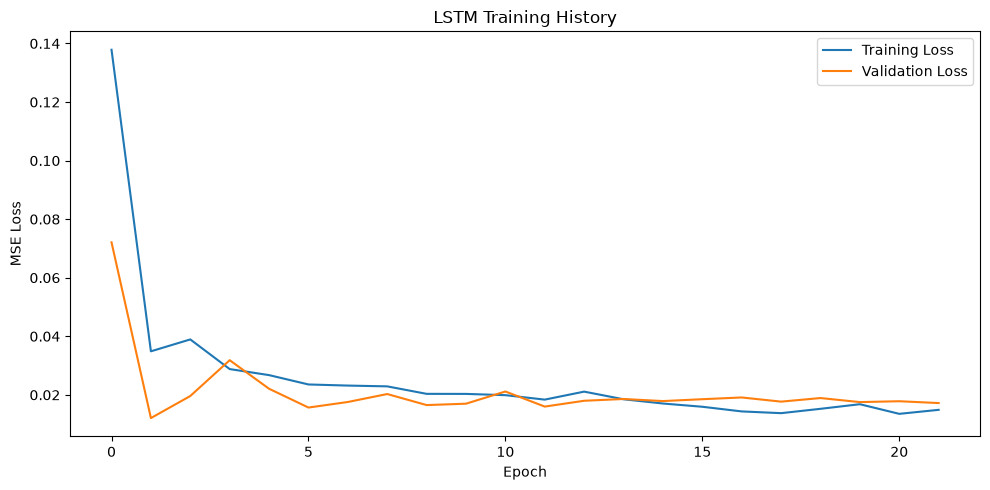

In [94]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training History")
plt.legend()

plt.tight_layout()
plt.show()

In [95]:
combined = pd.concat(
    [
        train_df.tail(LOOKBACK),
        test_df
    ],
    ignore_index=True
)

combined_scaled = feature_scaler.transform(
    combined[features]
)

In [96]:
X_test, _ = create_sequences(
    combined_scaled,
    np.zeros(len(combined_scaled)),
    LOOKBACK
)

In [97]:
X_test = X_test[:len(test_df)]
X_test.shape

(24, 12, 2)

#### Predict

In [98]:
pred_scaled = model.predict(
    X_test,
    verbose=0
)

In [99]:
predicted_food_inflation = (
    target_scaler.inverse_transform(
        pred_scaled
    )
    .flatten()
)

In [100]:
predictions = pd.DataFrame({
    "date": test_df["date"].values,
    "actual_food_inflation": (
        test_df["food_inflation"].values
    ),
    "predicted_food_inflation": (
        predicted_food_inflation
    )
})

display(predictions.head())

,date,actual_food_inflation,predicted_food_inflation
0,2024-01-01,8.30,10.134334
1,2024-02-01,8.66,10.661716
2,2024-03-01,8.52,11.091959
3,2024-04-01,8.70,11.420741
4,2024-05-01,8.69,11.638005


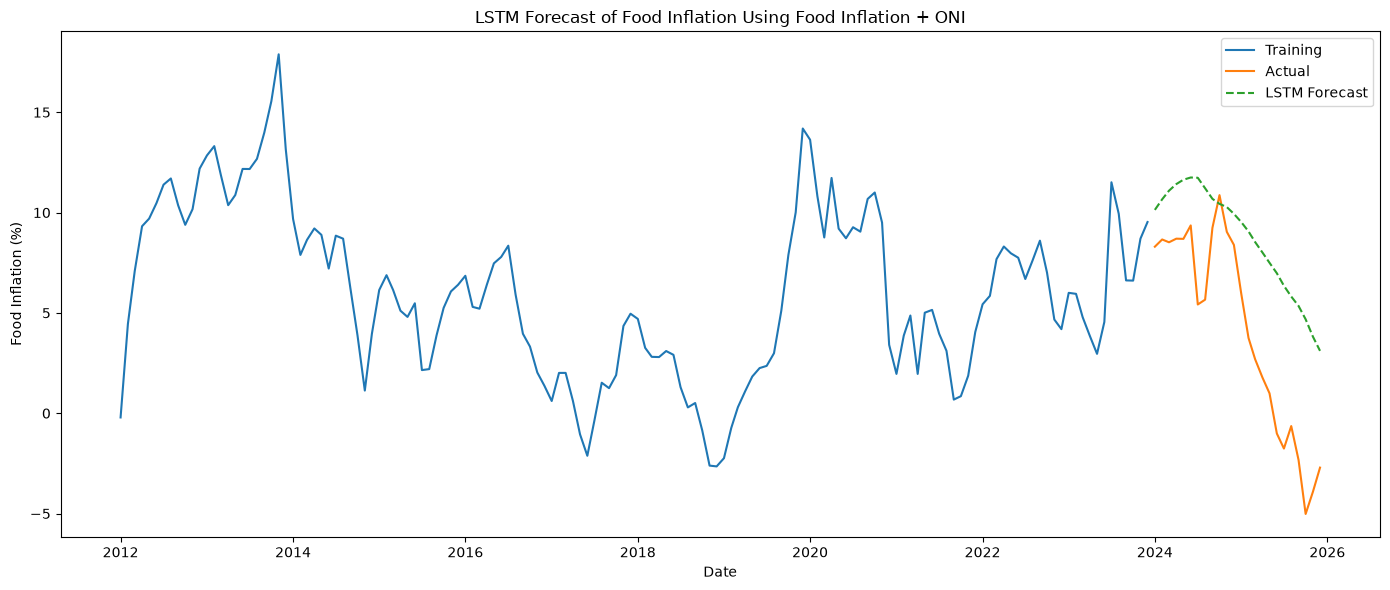

In [101]:
plt.figure(figsize=(14, 6))

plt.plot(
    train_df["date"],
    train_df["food_inflation"],
    label="Training"
)

plt.plot(
    test_df["date"],
    test_df["food_inflation"],
    label="Actual"
)

plt.plot(
    predictions["date"],
    predictions["predicted_food_inflation"],
    linestyle="--",
    label="LSTM Forecast"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("LSTM Forecast of Food Inflation Using Food Inflation + ONI")
plt.legend()

plt.tight_layout()
plt.show()

In [102]:
predictions.to_csv(
    "../data/processed/lstm_predictions.csv",
    index=False
)

### <mark>**LSTM baseline**</mark>

In [103]:
features_baseline = ["food_inflation"]

baseline_scaler = MinMaxScaler()

train_baseline_scaled = baseline_scaler.fit_transform(
    train_df[features_baseline]
)

test_baseline_scaled = baseline_scaler.transform(
    test_df[features_baseline]
)

In [104]:
baseline_target_scaler = MinMaxScaler()

baseline_target_scaler.fit(
    train_df[["food_inflation"]]
)

train_baseline_target_scaled = baseline_target_scaler.transform(
    train_df[["food_inflation"]]
).flatten()

In [105]:
X_baseline_full, y_baseline_full = create_sequences(
    train_baseline_scaled,
    train_baseline_target_scaled,
    LOOKBACK
)

print("X shape:", X_baseline_full.shape)
print("y shape:", y_baseline_full.shape)

X shape: (132, 12, 1)
y shape: (132,)


In [106]:
X_baseline_train = X_baseline_full[:-VALIDATION_SIZE]
y_baseline_train = y_baseline_full[:-VALIDATION_SIZE]

X_baseline_val = X_baseline_full[-VALIDATION_SIZE:]
y_baseline_val = y_baseline_full[-VALIDATION_SIZE:]

print("Training samples:", len(X_baseline_train))
print("Validation samples:", len(X_baseline_val))

Training samples: 108
Validation samples: 24


In [107]:
baseline_model = Sequential([
    LSTM(
        64,
        input_shape=(
            LOOKBACK,
            len(features_baseline)
        )
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])
baseline_model.compile(
    optimizer="adam",
    loss="mse"
)

baseline_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [109]:
baseline_history = baseline_model.fit(
    X_baseline_train,
    y_baseline_train,
    validation_data=(
        X_baseline_val,
        y_baseline_val
    ),
    epochs=300,
    batch_size=16,
    callbacks=[baseline_early_stopping],
    verbose=1
)

Epoch 1/300


7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 324ms/step - loss: 0.1029 - val_loss: 0.0447
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0286 - val_loss: 0.0149
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - loss: 0.0338 - val_loss: 0.0158
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 383ms/step - loss: 0.0265 - val_loss: 0.0256
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.0241 - val_loss: 0.0182
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - loss: 0.0215 - val_loss: 0.0139
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0249 - val_loss: 0.0149
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0212 - val_loss: 0.0158
Epoch 9/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0189 - val_loss: 0.0150
Epoch 10/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - loss: 0.0184 - val_loss: 0.0143
Epoch 11/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0169 - val_loss: 0.0152
Epoch 12/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0201 - val_loss: 0

In [110]:
print("Best validation loss:",
      min(baseline_history.history["val_loss"]))

print("Best epoch:",
      np.argmin(baseline_history.history["val_loss"]) + 1)

Best validation loss: 0.007903004996478558
Best epoch: 161


In [111]:
# Combine the last 12 training months with the test data
baseline_test_input = pd.concat(
    [
        train_df[features_baseline].tail(LOOKBACK),
        test_df[features_baseline]
    ],
    ignore_index=True
)

# Scale using the scaler fitted on training data
baseline_test_scaled = baseline_scaler.transform(
    baseline_test_input
)

print("Test input shape:", baseline_test_scaled.shape)

Test input shape: (36, 1)


In [112]:
X_baseline_test = []

for i in range(
    LOOKBACK,
    len(baseline_test_scaled)
):
    X_baseline_test.append(
        baseline_test_scaled[i - LOOKBACK:i]
    )

X_baseline_test = np.array(X_baseline_test)

print("X_test shape:", X_baseline_test.shape)

X_test shape: (24, 12, 1)


In [113]:
baseline_pred_scaled = baseline_model.predict(
    X_baseline_test
)

print("Prediction shape:", baseline_pred_scaled.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction shape: (24, 1)


In [114]:
baseline_predicted_food_inflation = (
    baseline_target_scaler.inverse_transform(
        baseline_pred_scaled
    ).flatten()
)

print(
    baseline_predicted_food_inflation[:5]
)

[9.359286  7.9320717 8.702924  8.378218  8.550745 ]


In [115]:
baseline_predictions = pd.DataFrame({
    "date": test_df["date"].values,
    "actual_food_inflation": (
        test_df["food_inflation"].values
    ),
    "predicted_food_inflation": (
        baseline_predicted_food_inflation
    )
})

display(baseline_predictions.head())

,date,actual_food_inflation,predicted_food_inflation
0,2024-01-01,8.30,9.359286
1,2024-02-01,8.66,7.932072
2,2024-03-01,8.52,8.702924
3,2024-04-01,8.70,8.378218
4,2024-05-01,8.69,8.550745


In [116]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = baseline_predictions["actual_food_inflation"]
predicted = baseline_predictions["predicted_food_inflation"]

mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

smape = np.mean(
    2 * np.abs(actual - predicted) /
    (np.abs(actual) + np.abs(predicted))
) * 100

print("Baseline LSTM MAE:", mae)
print("Baseline LSTM RMSE:", rmse)
print("Baseline LSTM sMAPE:", smape)

Baseline LSTM MAE: 1.28124409755071
Baseline LSTM RMSE: 1.60785255734922
Baseline LSTM sMAPE: 42.25458496258446


In [117]:
train_actual = train_df["food_inflation"].values

naive_errors = np.abs(
    train_actual[1:] - train_actual[:-1]
)

mae_naive = np.mean(naive_errors)

mase = mae / mae_naive

print("Baseline LSTM MASE:", mase)

Baseline LSTM MASE: 0.9521713677631185


In [118]:
print(model)

<Sequential name=sequential_3, built=True>


In [119]:
actual_lstm = lstm_predictions["actual_food_inflation"]
predicted_lstm = lstm_predictions["predicted_food_inflation"]

mae_lstm = mean_absolute_error(
    actual_lstm,
    predicted_lstm
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        actual_lstm,
        predicted_lstm
    )
)

smape_lstm = np.mean(
    2 * np.abs(actual_lstm - predicted_lstm) /
    (np.abs(actual_lstm) + np.abs(predicted_lstm))
) * 100

print("LSTM + ONI MAE:", mae_lstm)
print("LSTM + ONI RMSE:", rmse_lstm)
print("LSTM + ONI sMAPE:", smape_lstm)

LSTM + ONI MAE: 3.756202028989792
LSTM + ONI RMSE: 4.527661596078
LSTM + ONI sMAPE: 87.56544010988777


In [120]:
train_actual = train_df["food_inflation"].values

naive_errors = np.abs(
    train_actual[1:] - train_actual[:-1]
)

mae_naive = np.mean(naive_errors)

mase_lstm = mae_lstm / mae_naive

print("LSTM + ONI MASE:", mase_lstm)

LSTM + ONI MASE: 2.791464975624019


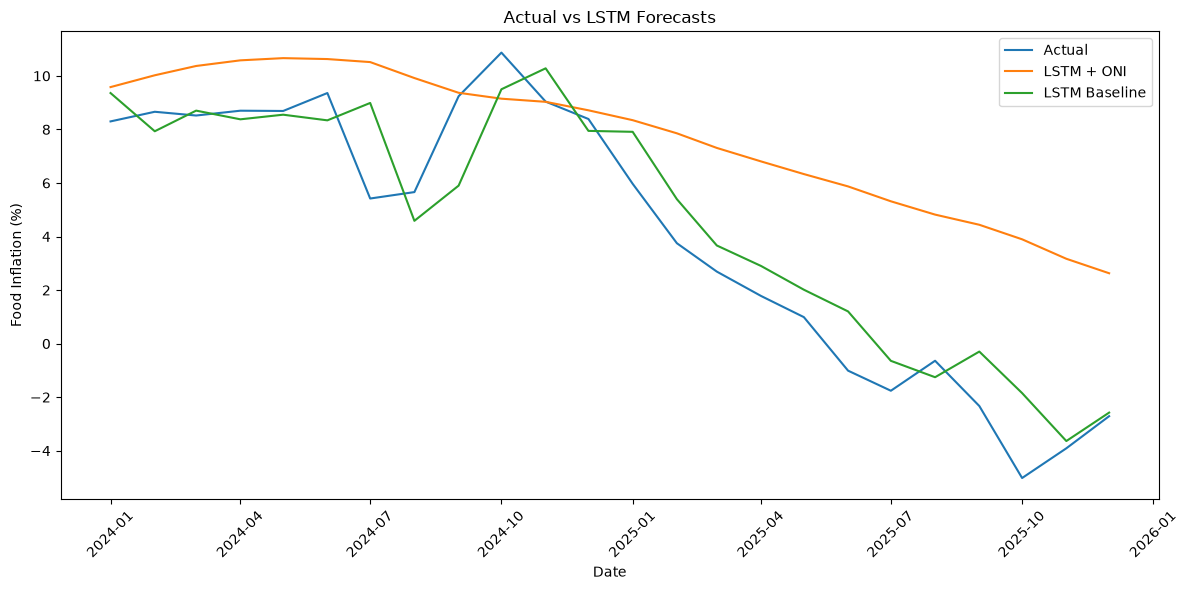

In [121]:
plt.figure(figsize=(12, 6))

plt.plot(
    lstm_predictions["date"],
    lstm_predictions["actual_food_inflation"],
    label="Actual"
)

plt.plot(
    lstm_predictions["date"],
    lstm_predictions["predicted_food_inflation"],
    label="LSTM + ONI"
)

plt.plot(
    baseline_predictions["date"],
    baseline_predictions["predicted_food_inflation"],
    label="LSTM Baseline"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("Actual vs LSTM Forecasts")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()